In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display setting
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
# plot Style
sns.set_style("whitegrid")


In [2]:
# Loading Dataset
df=pd.read_csv("Student_performance.csv")
# Displaing First 5rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [3]:
# Shapeof Data
print("Number of rows:",[0])
print("Number of Columns:",[1])
print("Dtaset Shape:",df.shape)

Number of rows: [0]
Number of Columns: [1]
Dtaset Shape: (649, 33)


In [4]:
# Columns Name
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns in the dataset:

1 - school
2 - sex
3 - age
4 - address
5 - famsize
6 - Pstatus
7 - Medu
8 - Fedu
9 - Mjob
10 - Fjob
11 - reason
12 - guardian
13 - traveltime
14 - studytime
15 - failures
16 - schoolsup
17 - famsup
18 - paid
19 - activities
20 - nursery
21 - higher
22 - internet
23 - romantic
24 - famrel
25 - freetime
26 - goout
27 - Dalc
28 - Walc
29 - health
30 - absences
31 - G1
32 - G2
33 - G3


In [5]:
# Basic Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [6]:
# Missing Value
missing_values=df.isnull().sum()
print("Missing Value In Each Column:")
print(missing_values)

Missing Value In Each Column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


# No Missing Value in my Dataset

In [7]:
# Checking Total Missing Value
print("Total Missing Value:",df.isnull().sum().sum())

Total Missing Value: 0


In [8]:
# Applying Condition
if df.isnull().sum().sum() == 0:
    print("No missing values found. No imputation was required.")
else:
    print("Missing values found. Further treatment is required.")

No missing values found. No imputation was required.


In [9]:
# Checking Duplicate Record
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
df[df.duplicated()]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


In [11]:
# Handling Duplicate
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [12]:
# Checking Data Errors
print("Age range:", df["age"].min(), "to", df["age"].max())
print("G1 range:", df["G1"].min(), "to", df["G1"].max())
print("G2 range:", df["G2"].min(), "to", df["G2"].max())
print("G3 range:", df["G3"].min(), "to", df["G3"].max())
print("Absences range:", df["absences"].min(), "to", df["absences"].max())

Age range: 15 to 22
G1 range: 0 to 19
G2 range: 0 to 19
G3 range: 0 to 19
Absences range: 0 to 32


In [13]:

# Checking Invalid Grade
invalid_grades = df[
    (df["G1"] < 0) | (df["G1"] > 20) |
    (df["G2"] < 0) | (df["G2"] > 20) |
    (df["G3"] < 0) | (df["G3"] > 20)
]

print("Invalid grade records:", len(invalid_grades))

Invalid grade records: 0


In [14]:
# Checking Negative Abcense
invalid_absences = df[df["absences"] < 0]

print("Negative absence records:", len(invalid_absences))

Negative absence records: 0


In [15]:
# Data Cleaning
print("Final dataset shape after basic cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape after basic cleaning: (649, 33)
Missing values: 0
Duplicate rows: 0


In [16]:
#Descriptive Statistics
numeric_columns = df.select_dtypes(include=np.number).columns

summary_statistics = pd.DataFrame({
    "Count": df[numeric_columns].count(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": [
        df[column].mode().iloc[0]
        if not df[column].mode().empty
        else np.nan
        for column in numeric_columns
    ],
    "Standard Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

summary_statistics = summary_statistics.round(2)

summary_statistics

,Count,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
age,649,16.74,17.0,17,1.22,15,22
Medu,649,2.51,2.0,2,1.13,0,4
Fedu,649,2.31,2.0,2,1.10,0,4
traveltime,649,1.57,1.0,1,0.75,1,4
studytime,649,1.93,2.0,2,0.83,1,4
failures,649,0.22,0.0,0,0.59,0,3
famrel,649,3.93,4.0,4,0.96,1,5
freetime,649,3.18,3.0,3,1.05,1,5
goout,649,3.18,3.0,3,1.18,1,5
Dalc,649,1.50,1.0,1,0.92,1,5


In [17]:

# Saving Statistics
summary_statistics.to_csv("summary_statistics.csv")

In [18]:
# Final Grade Statistics
print("Final Grade Statistics")

print("Mean:", df["G3"].mean())
print("Median:", df["G3"].median())
print("Mode:", df["G3"].mode()[0])
print("Standard Deviation:", df["G3"].std())
print("Minimum:", df["G3"].min())
print("Maximum:", df["G3"].max())

Final Grade Statistics
Mean: 11.906009244992296
Median: 12.0
Mode: 11
Standard Deviation: 3.2306562428048045
Minimum: 0
Maximum: 19


In [20]:
# Gender Wise Analysis
gender_analysis = df.groupby("sex")["G3"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

gender_analysis

,count,mean,median,min,max
sex,,,,,
F,383,12.25,12.0,0,19
M,266,11.41,11.0,0,19


In [21]:
# Study Time Analysis
studytime_analysis = df.groupby("studytime")["G3"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

studytime_analysis

,count,mean,median,min,max
studytime,,,,,
1,212,10.84,11.0,0,18
2,305,12.09,12.0,0,19
3,97,13.23,13.0,8,18
4,35,13.06,13.0,6,19


In [22]:
# Previous Failure Vs Final grade
failure_analysis = df.groupby("failures")["G3"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

failure_analysis

,count,mean,median,min,max
failures,,,,,
0,549,12.51,12.0,0,19
1,70,8.64,10.0,0,16
2,16,8.81,9.5,0,15
3,14,8.07,8.5,0,11


In [23]:
# School Wise Analysis
school_analysis = df.groupby("school")["G3"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

school_analysis

,count,mean,median,min,max
school,,,,,
GP,423,12.58,13.0,0,19
MS,226,10.65,11.0,0,19


In [24]:
# Pass FailurevAnalysis
df["Result"] = np.where(df["G3"] >= 10, "Pass", "Fail")

df["Result"].value_counts()

Result
Pass    549
Fail    100
Name: count, dtype: int64

In [25]:
# Passing Percentage
pass_rate = (df["Result"] == "Pass").mean() * 100

print(f"Overall Pass Rate: {pass_rate:.2f}%")

Overall Pass Rate: 84.59%


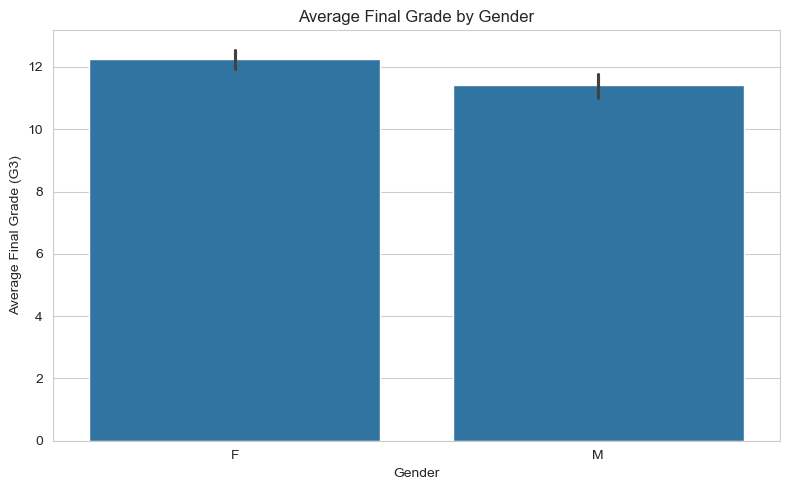

In [26]:
# Average Final Grade By Gender By Bar Chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="sex",
    y="G3",
    estimator=np.mean
)

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade (G3)")

plt.tight_layout()
plt.savefig("01_average_grade_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
#Report
#This chart compares the average final grade (G3) between male and female students.
#The group with the higher average G3 achieved better overall final academic performance.

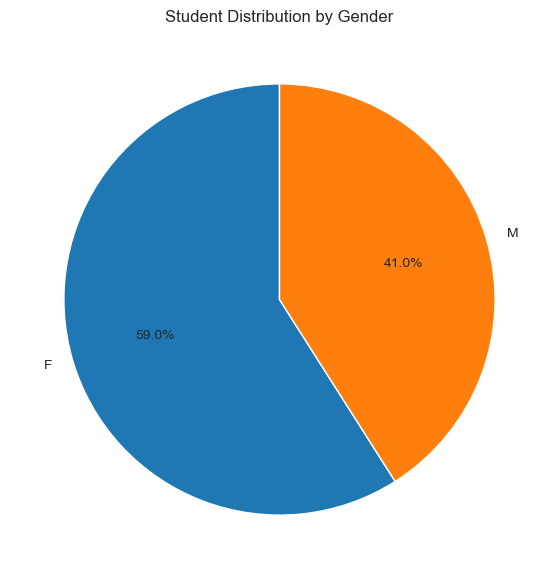

In [28]:
# Gender Distribution By Using Pie Chart
gender_counts = df["sex"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Distribution by Gender")

plt.savefig("02_gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Report
#The pie chart shows the proportion of male and female students in the dataset.
#It helps us understand the gender composition of the students included in the analysis.

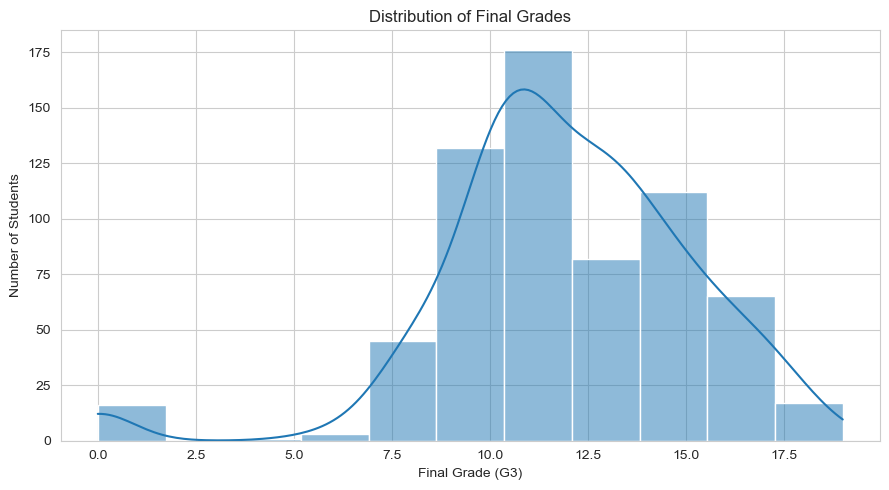

In [30]:
# Final Grade Distribution BY Histogram
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=11,
    kde=True
)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.savefig("03_final_grade_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# reporting
#The histogram shows how final grades are distributed among students.
#It helps identify the most common grade range and whether the distribution is concentrated or spread out.

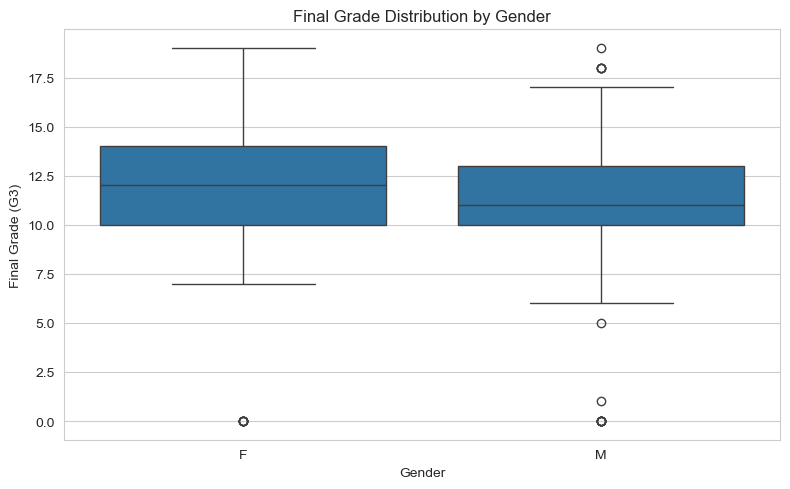

In [32]:
# Final Grade By Gender Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sex",
    y="G3"
)

plt.title("Final Grade Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.savefig("04_final_grade_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
#reporting
#The box plot compares the distribution and spread of final grades between genders.
#It also helps identify unusually high or low grades and differences in variability.

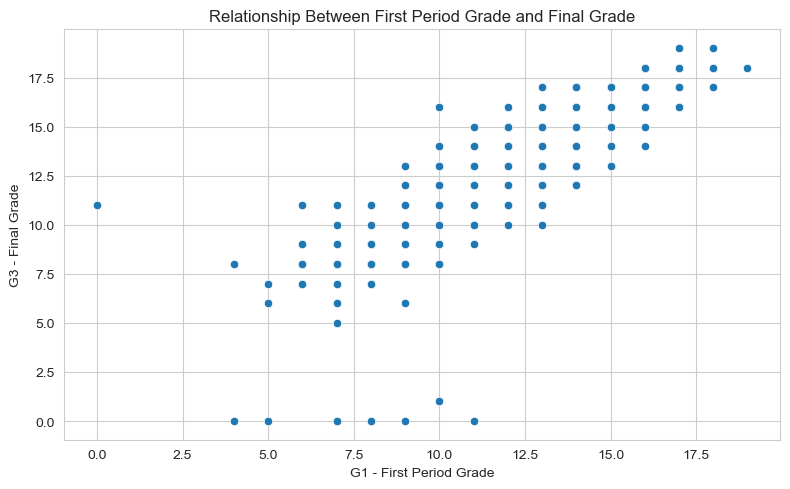

In [35]:
#G1 Vs G3
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="G1",
    y="G3"
)

plt.title("Relationship Between First Period Grade and Final Grade")
plt.xlabel("G1 - First Period Grade")
plt.ylabel("G3 - Final Grade")

plt.tight_layout()
plt.savefig("05_G1_vs_G3.png", dpi=300, bbox_inches="tight")
#plt.show()

In [36]:
# Reporting
#The scatter plot shows the relationship between the first-period grade (G1) and final grade (G3).
#A clear upward pattern would indicate that students with higher earlier grades tend to have higher final grades.

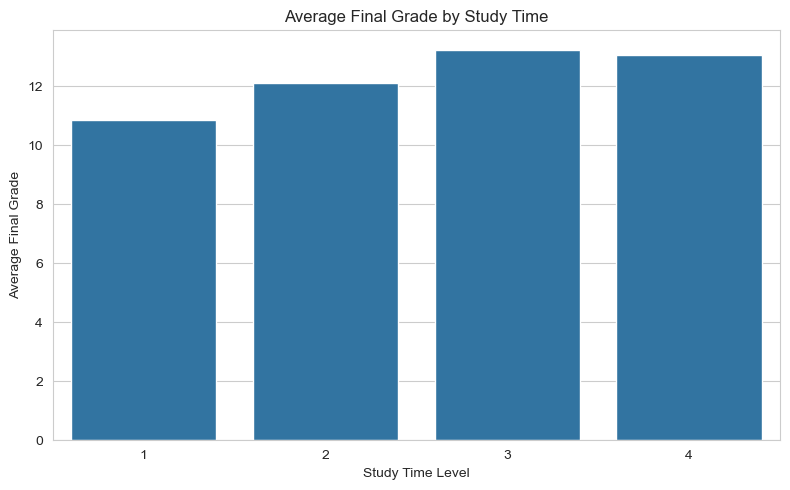

In [37]:
#Study Time Vs Final Grade Bar Graph
studytime_mean = df.groupby("studytime")["G3"].mean()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=studytime_mean.index,
    y=studytime_mean.values
)

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average Final Grade")

plt.tight_layout()
plt.savefig("06_studytime_vs_grade.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
# Reporting
#This chart compares final academic performance across different study-time levels.
#It helps investigate whether greater study time is associated with higher final grades.

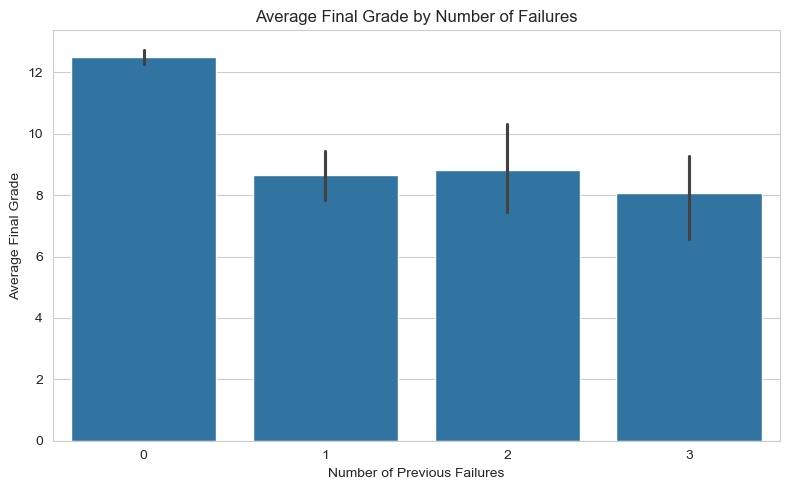

In [39]:
# Failure Vs Final Grade
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Average Final Grade by Number of Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade")

plt.tight_layout()
plt.savefig("07_failures_vs_grade.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# reporting
#The chart compares average final grades according to the number of previous failures.
#It helps identify whether students with more previous failures tend to have lower final academic performance.

In [41]:
# Outlier Analysis
def find_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))

    return outliers

In [42]:
# Absence outlier
absence_outliers = find_outliers("absences")

Column: absences
Q1: 0.0
Q3: 6.0
IQR: 6.0
Lower Limit: -9.0
Upper Limit: 15.0
Number of Outliers: 21


In [44]:
#Diplaying
absence_outliers[["age", "sex", "absences", "G3"]]

,age,sex,absences,G3
40,16,F,16,10
103,15,F,16,10
150,15,F,24,9
155,17,M,22,6
161,16,M,16,8
197,17,F,32,14
206,17,M,16,12
211,16,M,16,12
212,17,F,30,16
217,17,F,21,13


In [45]:
# Grade Outliers
grade_outliers = find_outliers("G3")

Column: G3
Q1: 10.0
Q3: 14.0
IQR: 4.0
Lower Limit: 4.0
Upper Limit: 20.0
Number of Outliers: 16


In [46]:
# Coorelation Analysis Cirrelation Table
correlation = df[numeric_columns].corr().round(2)

correlation

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.00,-0.11,-0.12,0.03,-0.01,0.32,-0.02,-0.00,0.11,0.13,0.09,-0.01,0.15,-0.17,-0.11,-0.11
Medu,-0.11,1.00,0.65,-0.27,0.10,-0.17,0.02,-0.02,0.01,-0.01,-0.02,0.00,-0.01,0.26,0.26,0.24
Fedu,-0.12,0.65,1.00,-0.21,0.05,-0.17,0.02,0.01,0.03,0.00,0.04,0.04,0.03,0.22,0.23,0.21
traveltime,0.03,-0.27,-0.21,1.00,-0.06,0.10,-0.01,0.00,0.06,0.09,0.06,-0.05,-0.01,-0.15,-0.15,-0.13
studytime,-0.01,0.10,0.05,-0.06,1.00,-0.15,-0.00,-0.07,-0.08,-0.14,-0.21,-0.06,-0.12,0.26,0.24,0.25
failures,0.32,-0.17,-0.17,0.10,-0.15,1.00,-0.06,0.11,0.05,0.11,0.08,0.04,0.12,-0.38,-0.39,-0.39
famrel,-0.02,0.02,0.02,-0.01,-0.00,-0.06,1.00,0.13,0.09,-0.08,-0.09,0.11,-0.09,0.05,0.09,0.06
freetime,-0.00,-0.02,0.01,0.00,-0.07,0.11,0.13,1.00,0.35,0.11,0.12,0.08,-0.02,-0.09,-0.11,-0.12
goout,0.11,0.01,0.03,0.06,-0.08,0.05,0.09,0.35,1.00,0.25,0.39,-0.02,0.09,-0.07,-0.08,-0.09
Dalc,0.13,-0.01,0.00,0.09,-0.14,0.11,-0.08,0.11,0.25,1.00,0.62,0.06,0.17,-0.20,-0.19,-0.20


In [47]:
# Correlation With Final Grade
grade_correlation = correlation["G3"].sort_values(ascending=False)

print("Correlation with Final Grade (G3):")
grade_correlation

Correlation with Final Grade (G3):


G3            1.00
G2            0.92
G1            0.83
studytime     0.25
Medu          0.24
Fedu          0.21
famrel        0.06
goout        -0.09
absences     -0.09
health       -0.10
age          -0.11
freetime     -0.12
traveltime   -0.13
Walc         -0.18
Dalc         -0.20
failures     -0.39
Name: G3, dtype: float64

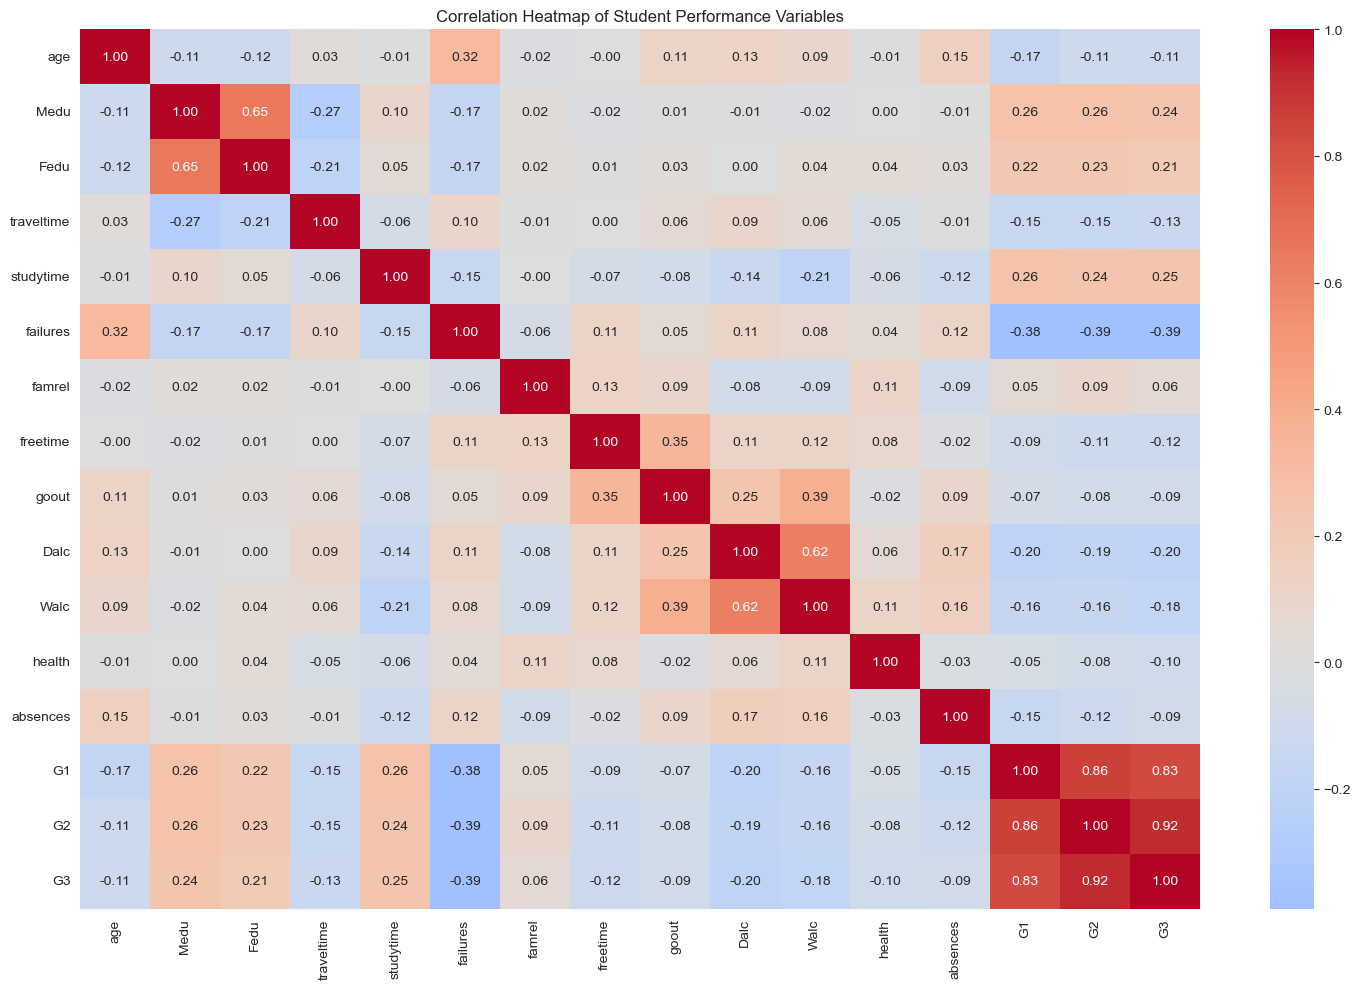

In [48]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Student Performance Variables")

plt.tight_layout()
plt.savefig("08_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Reporting
#T#he correlation heatmap shows the strength and direction of relationships between numerical variables.
#Variables with values closer to +1 have stronger positive relationships, while values closer to -1 have stronger negative relationships.
#Correlation indicates association and does not by itself prove causation.

In [51]:
# Absemce Vs final Grade
absence_correlation = df["absences"].corr(df["G3"])

print(f"Correlation between absences and final grade: {absence_correlation:.2f}")

Correlation between absences and final grade: -0.09


In [52]:
#Study Time and Final Grade
study_correlation = df["studytime"].corr(df["G3"])

print(f"Correlation between study time and final grade: {study_correlation:.2f}")

Correlation between study time and final grade: 0.25


In [53]:
# G1 G2 G3 Correlation
grade_corr = df[["G1", "G2", "G3"]].corr().round(2)

grade_corr

,G1,G2,G3
G1,1.00,0.86,0.83
G2,0.86,1.00,0.92
G3,0.83,0.92,1.00


In [55]:
# Best Group Gender
gender_means = df.groupby("sex")["G3"].mean()

best_gender = gender_means.idxmax()
best_gender_score = gender_means.max()

print(
    f"The gender group with the highest average final grade is "
    f"{best_gender} with an average G3 of {best_gender_score:.2f}."
)

The gender group with the highest average final grade is F with an average G3 of 12.25.


In [57]:
# Best Study Time Group
study_means = df.groupby("studytime")["G3"].mean()

best_studytime = study_means.idxmax()
best_study_score = study_means.max()

print(
    f"The study-time group with the highest average G3 is "
    f"studytime level {best_studytime}, with an average of {best_study_score:.2f}."
)

The study-time group with the highest average G3 is studytime level 3, with an average of 13.23.


In [58]:
# FailureAnalysis
failure_means = df.groupby("failures")["G3"].mean()

best_failure_group = failure_means.idxmax()
lowest_failure_group = failure_means.idxmin()

print(
    f"Highest average G3 occurs among students with "
    f"{best_failure_group} previous failures: {failure_means.max():.2f}"
)

print(
    f"Lowest average G3 occurs among students with "
    f"{lowest_failure_group} previous failures: {failure_means.min():.2f}"
)

Highest average G3 occurs among students with 0 previous failures: 12.51
Lowest average G3 occurs among students with 3 previous failures: 8.07


In [59]:
# Top Finding For Report
print("========== TOP 5 FINDINGS ==========\n")

print(f"1. Average final grade (G3): {df['G3'].mean():.2f}")

print(
    f"2. Median final grade (G3): "
    f"{df['G3'].median():.2f}"
)

print(
    f"3. Overall pass rate: "
    f"{(df['G3'] >= 10).mean() * 100:.2f}%"
)

print(
    f"4. Correlation between G1 and G3: "
    f"{df['G1'].corr(df['G3']):.2f}"
)

print(
    f"5. Correlation between absences and G3: "
    f"{df['absences'].corr(df['G3']):.2f}"
)

========== TOP 5 FINDINGS ==========

1. Average final grade (G3): 11.91
2. Median final grade (G3): 12.00
3. Overall pass rate: 84.59%
4. Correlation between G1 and G3: 0.83
5. Correlation between absences and G3: -0.09


In [60]:
# Overall Conclution
## Conclusion

#The Student Performance Analysis explored the factors associated with students' final academic performance.

### Top Five Findings

#1. The average final grade provides an overview of overall student performance.
#2. Gender-wise analysis shows differences in average academic performance between groups.
#3. Study-time analysis helps evaluate whether study habits are associated with final grades.
#4. Previous failures can be compared with final grades to identify academic performance patterns.
#5. Correlation analysis helps identify variables that are strongly associated with the final grade.

#Overall, the analysis provides useful insights into student performance and highlights factors that may be associated with academic outcomes. However, correlation should not be interpreted as proof of causation.

#The Student Performance Analysis explored the factors associated with students' final academic performance.

In [61]:
# Sving Cleaned Dataset
df.to_csv("student_performance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [62]:
# List Generated File
import os

files = os.listdir()

for file in files:
    if file.endswith(".png") or file.endswith(".csv"):
        print(file)

01_average_grade_by_gender.png
02_gender_distribution.png
03_final_grade_distribution.png
04_final_grade_boxplot.png
05_G1_vs_G3.png
06_studytime_vs_grade.png
07_failures_vs_grade.png
08_correlation_heatmap.png
Cleaned_Retail_Sales_Dataset.csv
Dataset for Data Analytics.csv
Data_Cleaning_Change_Log.csv
EDA_Correlation_Matrix.csv
Student_performance.csv
student_performance_cleaned.csv
summary_statistics.csv
synthetic_dataset.csv
telecom_customer_churn.csv
